# Supplementary Figure S5 - WIOD Portability Example

Post hoc enrichment-based annotation of the WIOD 2014 country-sector input-output matrix. Rows are origin country-sectors, columns are destination country-sectors, and values are log1p-transformed intermediate flows. The notebook renders the annotated matrix, a condensed dendrogram, and a descriptive destination-flow summary for selected country-labeled clusters.


## Setup

Locate the repository, import shared utilities, and define output folders.


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    markers = ("himalayas_src", "data", ".git", "revision")
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not locate himalayas-publication repo root above {start}")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "revision" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Kernel CWD:  {Path.cwd()}")
print(f"Repo root:   {REPO_ROOT}")

Kernel CWD:  /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication
Repo root:   /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication


In [2]:
import re
import zipfile
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr

import revision_utils as ru
from revision_utils import revision_layout

layout = revision_layout(REPO_ROOT)
for key in ("manifests_dir", "tables_dir", "figures_dir", "scratch_dir", "executed_notebooks_dir"):
    layout[key].mkdir(parents=True, exist_ok=True)

NB_ID = "supp_fig_5"
NB_TABLES_DIR = layout["tables_dir"] / NB_ID
NB_FIGURES_DIR = layout["figures_dir"] / NB_ID
NB_SCRATCH_DIR = layout["scratch_dir"] / NB_ID
PNG_SUPP5_DIR = REPO_ROOT / "png" / "supp_fig_5"
PNG_SUPP6_DIR = REPO_ROOT / "png" / "supp_fig_6"
for d in (NB_TABLES_DIR, NB_FIGURES_DIR, NB_SCRATCH_DIR, PNG_SUPP5_DIR, PNG_SUPP6_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Tables  ->", NB_TABLES_DIR)
print("Figures ->", NB_FIGURES_DIR)
print("PNG S5  ->", PNG_SUPP5_DIR)
print("PNG S6  ->", PNG_SUPP6_DIR)
print("Scratch ->", NB_SCRATCH_DIR)

Tables  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/supp_fig_5
Figures -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/supp_fig_5
PNG S5  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/png/supp_fig_5
PNG S6  -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/png/supp_fig_6
Scratch -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/supp_fig_5


## Load WIOD

Download or reuse the cached WIOD 2016 release archive and extract the 2014 input-output table.


In [3]:
WIOD_DOI = "10.34894/PJ2M1C"
WIOD_DATAVERSE_FILE_ID = 199101  # WIOTS_in_R.zip, resolved via the Dataverse file-listing API
WIOD_ARCHIVE_URL = f"https://dataverse.nl/api/access/datafile/{WIOD_DATAVERSE_FILE_ID}"
WIOD_ARCHIVE_PATH = NB_SCRATCH_DIR / "WIOTS_in_R.zip"
WIOD_EXPECTED_SIZE_BYTES = 641_578_409  # confirmed via Dataverse API file listing (prior audit)
WIOD_YEAR = 2014
WIOD_RDATA_FILENAME = f"WIOT{WIOD_YEAR}_October16_ROW.RData"
WIOD_RDATA_PATH = NB_SCRATCH_DIR / WIOD_RDATA_FILENAME

download_attempted = False
download_timestamp_utc = None

if WIOD_ARCHIVE_PATH.exists() and WIOD_ARCHIVE_PATH.stat().st_size == WIOD_EXPECTED_SIZE_BYTES:
    print(f"Using cached archive: {WIOD_ARCHIVE_PATH} ({WIOD_ARCHIVE_PATH.stat().st_size:,} bytes)")
else:
    import urllib.request

    download_attempted = True
    print(f"Downloading {WIOD_ARCHIVE_URL} -> {WIOD_ARCHIVE_PATH}")
    urllib.request.urlretrieve(WIOD_ARCHIVE_URL, WIOD_ARCHIVE_PATH)
    download_timestamp_utc = ru.utc_timestamp()

archive_size_bytes = WIOD_ARCHIVE_PATH.stat().st_size
archive_sha256 = ru.sha256_file(WIOD_ARCHIVE_PATH)
size_verified = archive_size_bytes == WIOD_EXPECTED_SIZE_BYTES

print(f"Archive size:     {archive_size_bytes:,} bytes")
print(f"Expected size:    {WIOD_EXPECTED_SIZE_BYTES:,} bytes")
print(f"Size verified:    {size_verified}")
print(f"Archive sha256:   {archive_sha256}")

# Extract only the single 2014 RData member -- not the full 15-year archive.
with zipfile.ZipFile(WIOD_ARCHIVE_PATH) as zf:
    members = zf.namelist()
    assert WIOD_RDATA_FILENAME in members, (
        f"{WIOD_RDATA_FILENAME} not found in archive. Members: {members}"
    )
    if not WIOD_RDATA_PATH.exists():
        zf.extract(WIOD_RDATA_FILENAME, path=NB_SCRATCH_DIR)

print(f"Extracted member: {WIOD_RDATA_FILENAME}")
print(f"Extracted size:   {WIOD_RDATA_PATH.stat().st_size:,} bytes")


Using cached archive: /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/scratch/supp_fig_5/WIOTS_in_R.zip (641,578,409 bytes)


Archive size:     641,578,409 bytes
Expected size:    641,578,409 bytes
Size verified:    True
Archive sha256:   30b17452273ea4ae94b6cb015aacb112be3a8f8d27e0a0f35c1b5c584b60ce90
Extracted member: WIOT2014_October16_ROW.RData
Extracted size:   42,923,938 bytes


## Inspect Source Table

Read the RData object and confirm its row and column structure before building the matrix.


In [4]:
rdata_result = pyreadr.read_r(str(WIOD_RDATA_PATH))
assert list(rdata_result.keys()) == ["wiot"], f"Unexpected objects in RData: {list(rdata_result.keys())}"
wiot = rdata_result["wiot"]

print(f"Raw loaded shape: {wiot.shape}")
print(f"Columns (first 8): {list(wiot.columns[:8])}")
print(f"Columns (last 5):  {list(wiot.columns[-5:])}")
print(f"Unique countries ({wiot['Country'].nunique()}): {sorted(wiot['Country'].unique())}")

Raw loaded shape: (2472, 2690)
Columns (first 8): ['IndustryCode', 'IndustryDescription', 'Country', 'RNr', 'Year', 'AUS1', 'AUS2', 'AUS3']
Columns (last 5):  ['ROW58', 'ROW59', 'ROW60', 'ROW61', 'TOT']
Unique countries (45): ['AUS', 'AUT', 'BEL', 'BGR', 'BRA', 'CAN', 'CHE', 'CHN', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HRV', 'HUN', 'IDN', 'IND', 'IRL', 'ITA', 'JPN', 'KOR', 'LTU', 'LUX', 'LVA', 'MEX', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'ROW', 'RUS', 'SVK', 'SVN', 'SWE', 'TOT', 'TUR', 'TWN', 'USA']


## Build Intermediate-Flow Matrix

Extract the square country-sector by country-sector intermediate-use block. Rows are producers/sellers; columns are users/buyers. Final-demand columns, totals, value-added, and tax rows are excluded.


In [5]:
META_COLS = ["IndustryCode", "IndustryDescription", "Country", "RNr", "Year"]

# Row selection: all non-TOT rows are intermediate-industry rows (RNr 1-56 by construction).
row_mask = wiot["Country"] != "TOT"
row_meta = wiot.loc[row_mask, META_COLS].copy()
assert row_meta["RNr"].between(1, 56).all(), "Unexpected RNr outside the 1-56 intermediate range"
row_labels = (row_meta["Country"] + "_" + row_meta["IndustryCode"]).tolist()
assert len(row_labels) == len(set(row_labels)), "Row labels are not unique"

# Column selection: per-country columns with numeric suffix 1-56 only (excludes the
# per-country final-demand columns 57-61 and the single TOT column).
data_cols = [c for c in wiot.columns if c not in META_COLS]
col_pattern = re.compile(r"^([A-Z]{3})(\d+)$")
intermediate_cols = []
for c in data_cols:
    m = col_pattern.match(c)
    if m and 1 <= int(m.group(2)) <= 56:
        intermediate_cols.append(c)

print(f"Intermediate rows: {row_mask.sum()}")
print(f"Intermediate cols: {len(intermediate_cols)}")

# Build a country-sector code -> IndustryCode map (positional: sector order is
# identical across countries) to translate column suffixes into the same
# Country_IndustryCode label scheme used for rows.
rnr_to_industry_code = dict(
    zip(
        row_meta.loc[row_meta["Country"] == "AUS", "RNr"].astype(int),
        row_meta.loc[row_meta["Country"] == "AUS", "IndustryCode"],
    )
)

col_labels = []
for c in intermediate_cols:
    m = col_pattern.match(c)
    country, num = m.group(1), int(m.group(2))
    col_labels.append(f"{country}_{rnr_to_industry_code[num]}")

assert set(col_labels) == set(row_labels), "Row and column label universes do not match"

# Slice the square intermediate flow block. Row order follows the file's native order;
# columns are relabeled to match and reordered to align with the row order so the
# matrix is a proper square country-sector x country-sector block.
flow_block = wiot.loc[row_mask, intermediate_cols].copy()
flow_block.index = row_labels
flow_block.columns = col_labels
flow_block = flow_block[row_labels]  # align column order to row order

flow_block = flow_block.apply(pd.to_numeric, errors="coerce")
n_missing = int(flow_block.isna().sum().sum())
assert n_missing == 0, f"Unexpected {n_missing} missing values in the intermediate flow block"

print(f"Intermediate flow block shape: {flow_block.shape}")
print(f"Square: {flow_block.shape[0] == flow_block.shape[1]}")
print(f"Value range: [{flow_block.values.min():,.1f}, {flow_block.values.max():,.1f}] (millions USD)")


Intermediate rows: 2464
Intermediate cols: 2464
Intermediate flow block shape: (2464, 2464)
Square: True
Value range: [0.0, 800,356.3] (millions USD)


## Build Annotation Mapping

Use native WIOD metadata only: country labels and ISIC Rev.4 sector labels.


In [6]:
sector_meta = (
    row_meta.assign(label=row_labels)
    .drop_duplicates(subset="label")
    .set_index("label")
    .loc[row_labels]
)

sector_to_labels = defaultdict(set)
country_to_labels = defaultdict(set)
for label, industry_code, country in zip(
    sector_meta.index, sector_meta["IndustryCode"], sector_meta["Country"]
):
    sector_to_labels[industry_code].add(label)
    country_to_labels[country].add(label)

print(f"ISIC sector terms: {len(sector_to_labels)}")
print(f"Country terms:     {len(country_to_labels)}")

ISIC sector terms: 56
Country terms:     44


## Transform Matrix

Apply a single log1p transform and build the HiMaLAYAS matrix object.


In [7]:
log_flow_df = pd.DataFrame(
    np.log1p(flow_block.values),
    index=flow_block.index,
    columns=flow_block.columns,
)

import himalayas
from himalayas import Analysis, Annotations, Matrix

print(f"HiMaLAYAS version: {himalayas.__version__}")

matrix = Matrix(log_flow_df)
print(f"Matrix shape: {matrix.values.shape}")

HiMaLAYAS version: 0.0.16
Matrix shape: (2464, 2464)


## Cluster and Enrich

Cluster row flow profiles with the standard HiMaLAYAS chain, then test country and sector annotations with Benjamini-Hochberg FDR correction.


In [8]:
annotation_dict = {**sector_to_labels, **country_to_labels}
annotations = Annotations(annotation_dict, matrix)
print(f"Annotation terms retained: {len(annotations.terms)}")

N_ROWS = matrix.values.shape[0]
MIN_CLUSTER_SIZE = 20  # conservative, simple value: ~0.8% of 2,464 rows

print(f"Row count: {N_ROWS}")
print(f"min_cluster_size: {MIN_CLUSTER_SIZE} (conservative fixed value, documented here)")

import time

USE_OPTIMAL_ORDERING = True
_t0 = time.time()
try:
    analysis = Analysis(matrix, annotations).cluster(
        linkage_method="ward",
        linkage_metric="euclidean",
        linkage_threshold="auto",
        optimal_ordering=USE_OPTIMAL_ORDERING,
        min_cluster_size=MIN_CLUSTER_SIZE,
    )
    _elapsed = time.time() - _t0
    print(f"cluster() with optimal_ordering=True completed in {_elapsed:.1f}s")
except Exception as exc:
    print(f"optimal_ordering=True failed or was too slow ({exc}); falling back to False")
    USE_OPTIMAL_ORDERING = False
    _t0 = time.time()
    analysis = Analysis(matrix, annotations).cluster(
        linkage_method="ward",
        linkage_metric="euclidean",
        linkage_threshold="auto",
        optimal_ordering=USE_OPTIMAL_ORDERING,
        min_cluster_size=MIN_CLUSTER_SIZE,
    )
    _elapsed = time.time() - _t0
    print(f"cluster() with optimal_ordering=False completed in {_elapsed:.1f}s")

analysis = analysis.enrich(min_overlap=2).finalize(col_cluster=True)
results = analysis.results
results_sig = results.filter("qval <= 0.05")

print(f"All enriched rows:        {len(results.df):,}")
print(f"Significant rows (q<=0.05): {len(results_sig.df):,}")
print(results_sig.df.head(10))


Annotation terms retained: 100
Row count: 2464
min_cluster_size: 20 (conservative fixed value, documented here)


cluster() with optimal_ordering=True completed in 52.3s


All enriched rows:        392
Significant rows (q<=0.05): 133
   cluster term   k   K   n     N          pval         fe          qval
0       10  AUS  46  56  46  2464  2.885304e-88  44.000000  1.131039e-85
1       19  PRT  45  56  45  2464  6.345045e-86  44.000000  1.243629e-83
2       27  ITA  40  56  40  2464  1.008884e-74  44.000000  1.318275e-72
3        2  JPN  40  56  41  2464  4.109787e-73  42.926829  4.027591e-71
4       17  ROU  39  56  39  2464  1.439143e-72  44.000000  9.402402e-71
5       21  NOR  39  56  39  2464  1.439143e-72  44.000000  9.402402e-71
6       33  ESP  38  56  38  2464  1.939645e-70  44.000000  1.086201e-68
7        4  FIN  38  56  39  2464  7.509929e-69  42.871795  3.679865e-67
8       12  TUR  36  56  37  2464  1.103987e-64  42.810811  4.808479e-63
9       28  GBR  35  56  36  2464  1.241944e-62  42.777778  4.868421e-61


In [9]:
COUNTRY_NAME = {
    "AUS": "Australia", "AUT": "Austria", "BEL": "Belgium", "BGR": "Bulgaria",
    "BRA": "Brazil", "CAN": "Canada", "CHE": "Switzerland", "CHN": "China",
    "CYP": "Cyprus", "CZE": "Czech Republic", "DEU": "Germany", "DNK": "Denmark",
    "ESP": "Spain", "EST": "Estonia", "FIN": "Finland", "FRA": "France",
    "GBR": "United Kingdom", "GRC": "Greece", "HRV": "Croatia", "HUN": "Hungary",
    "IDN": "Indonesia", "IND": "India", "IRL": "Ireland", "ITA": "Italy",
    "JPN": "Japan", "KOR": "South Korea", "LTU": "Lithuania", "LUX": "Luxembourg",
    "LVA": "Latvia", "MEX": "Mexico", "MLT": "Malta", "NLD": "Netherlands",
    "NOR": "Norway", "POL": "Poland", "PRT": "Portugal", "ROU": "Romania",
    "ROW": "Rest of world", "RUS": "Russia", "SVK": "Slovakia", "SVN": "Slovenia",
    "SWE": "Sweden", "TUR": "Turkey", "TWN": "Taiwan", "USA": "United States",
}
assert set(COUNTRY_NAME) == set(country_to_labels), "Country name map must cover exactly the 44 WIOD countries"

# Short display labels for the official WIOD/ISIC sector descriptions.
SECTOR_ABBREV = {
    "A01": "Crop/animal production", "A02": "Forestry/logging", "A03": "Fishing/aquaculture",
    "B": "Mining/quarrying", "C10-C12": "Food/beverages/tobacco", "C13-C15": "Textiles/apparel/leather",
    "C16": "Wood products", "C17": "Paper products", "C18": "Printing",
    "C19": "Coke/refined petroleum", "C20": "Chemicals", "C21": "Pharmaceuticals",
    "C22": "Rubber/plastics", "C23": "Non-metallic minerals", "C24": "Basic metals",
    "C25": "Fabricated metal products", "C26": "Computer/electronic/optical", "C27": "Electrical equipment",
    "C28": "Machinery/equipment", "C29": "Motor vehicles", "C30": "Other transport equipment",
    "C31_C32": "Furniture/other manufacturing", "C33": "Repair/installation",
    "D35": "Electricity/gas/utilities", "E36": "Water supply", "E37-E39": "Waste management",
    "F": "Construction", "G45": "Motor vehicle trade/repair", "G46": "Wholesale trade",
    "G47": "Retail trade", "H49": "Land transport", "H50": "Water transport",
    "H51": "Air transport", "H52": "Warehousing/transport support", "H53": "Postal/courier",
    "I": "Accommodation/food service", "J58": "Publishing", "J59_J60": "Media production/broadcasting",
    "J61": "Telecommunications", "J62_J63": "IT/computer services", "K64": "Financial services",
    "K65": "Insurance/pension", "K66": "Financial auxiliary services", "L68": "Real estate",
    "M69_M70": "Legal/accounting/management", "M71": "Architectural/engineering",
    "M72": "Scientific research", "M73": "Advertising/market research",
    "M74_M75": "Other professional/scientific", "N": "Administrative/support services",
    "O84": "Public admin/defence", "P85": "Education", "Q": "Health/social work",
    "R_S": "Other services", "T": "Household activities", "U": "Extraterritorial organizations",
}
assert set(SECTOR_ABBREV) == set(sector_to_labels), "Sector abbreviation map must cover exactly the 56 WIOD sectors"


def readable_destination_label(code):
    """Convert a Country_SectorCode destination label to 'Country name | Sector label'."""
    country, sector = code.split("_", 1)
    return f"{COUNTRY_NAME[country]} | {SECTOR_ABBREV[sector]}"


print("Label maps validated: 44 countries, 56 sectors, both cover the full WIOD universe.")
print("Example:", "LUX_K64", "->", readable_destination_label("LUX_K64"))


def readable_annotation_term(term):
    """Convert native WIOD annotation terms to readable display labels.

    Country terms are stored as ISO3 codes; sector terms are stored as WIOD/ISIC
    codes. This function is presentation-only and leaves raw result tables intact.
    """
    if term in COUNTRY_NAME:
        return COUNTRY_NAME[term]
    if term in SECTOR_ABBREV:
        return SECTOR_ABBREV[term]
    return term


print("Readable display maps validated for 44 countries and 56 sectors.")


Label maps validated: 44 countries, 56 sectors, both cover the full WIOD universe.
Example: LUX_K64 -> Luxembourg | Financial services
Readable display maps validated for 44 countries and 56 sectors.


In [10]:
cluster_labels = results_sig.cluster_labels(rank_by="p", label_mode="top_term")
cluster_labels_readable = cluster_labels.copy()


def typed_annotation_label(term):
    if term in COUNTRY_NAME:
        return f"Country: {COUNTRY_NAME[term]}"
    if term in SECTOR_ABBREV:
        return f"Sector: {SECTOR_ABBREV[term]}"
    raise ValueError(f"Unexpected WIOD top annotation term: {term}")

cluster_labels_readable["label_readable"] = cluster_labels_readable["label"].map(typed_annotation_label)
CLUSTER_LABEL_OVERRIDES = dict(
    zip(cluster_labels_readable["cluster"].astype(int), cluster_labels_readable["label_readable"])
)
assert len(CLUSTER_LABEL_OVERRIDES) == len(cluster_labels)

print(f"Typed readable cluster-label overrides prepared: {len(CLUSTER_LABEL_OVERRIDES)}")
print("Example:", "CYP", "->", typed_annotation_label("CYP"), ";", "C29", "->", typed_annotation_label("C29"))

Readable cluster-label overrides prepared: 42
Example: CYP -> Cyprus ; C29 -> Motor vehicles


## Render Annotated Matrix

Show the clustered flow matrix with enrichment labels and a capped enrichment track.


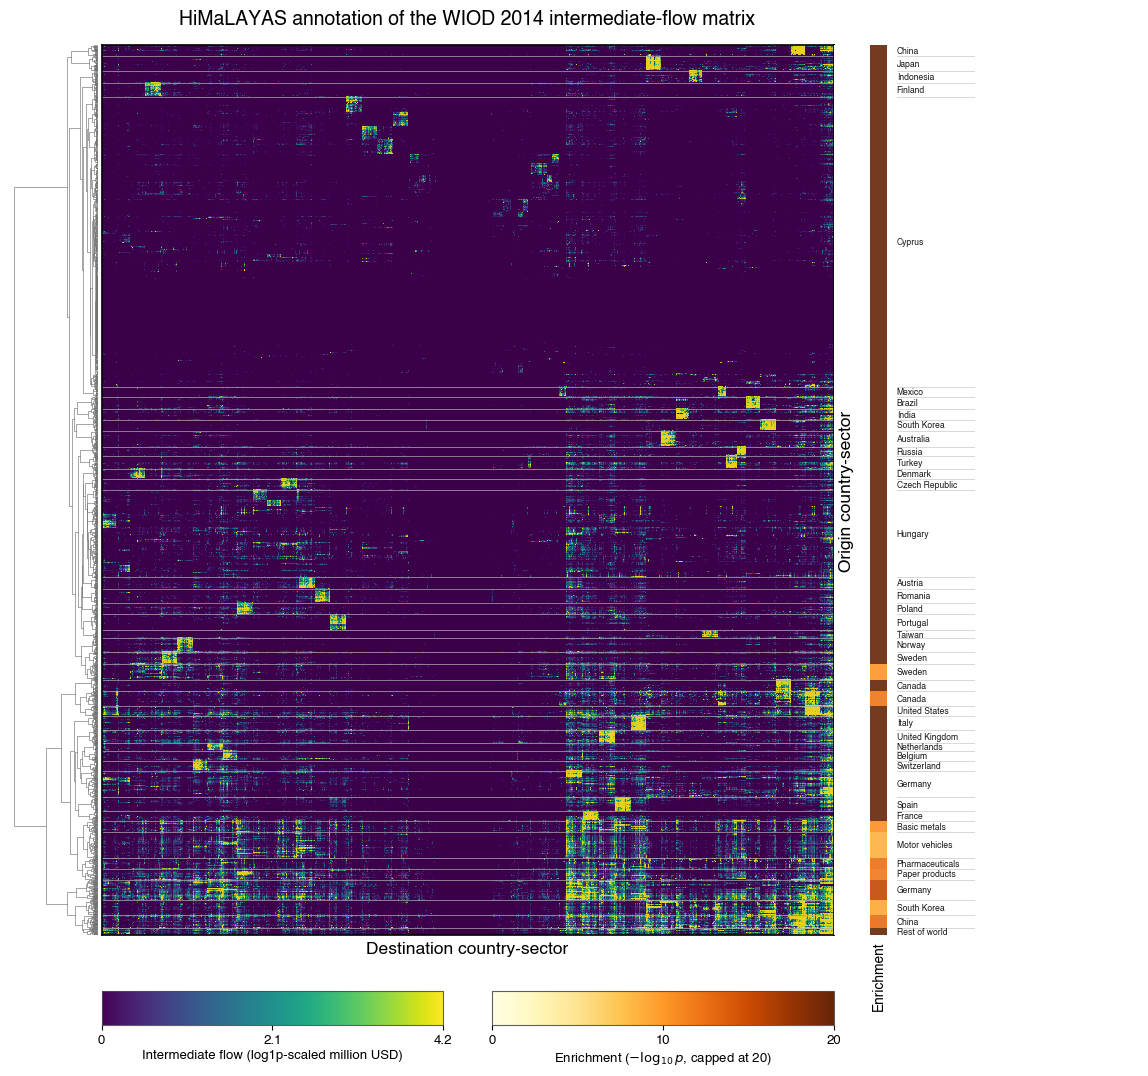

Saved figure -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/supp_fig_5/wiod_2014_annotated_matrix.png
Saved PNG    -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/png/supp_fig_5/wiod_2014_annotated_matrix.png


In [11]:
from himalayas.plot import Plotter

LABEL_COLOR = "white"
BACKGROUND_COLOR = "black"
DENDRO_COLOR = "#9a9a9a"
BOUNDARY_COLOR = "#e0e0e0"
FONT = "Helvetica"

vmax = float(np.quantile(log_flow_df.values, 0.99))
enrichment_norm_max = 20.0

plotter = (
    Plotter(results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_title(
        "HiMaLAYAS annotation of the WIOD 2014 intermediate-flow matrix",
        color=LABEL_COLOR,
        font=FONT,
        fontsize=14,
    )
    .plot_dendrogram(
        axes=[0.055, 0.075, 0.075, 0.84],
        data_pad=0.72,
        color=DENDRO_COLOR,
        linewidth=0.45,
    )
    .plot_matrix(
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        figsize=(12.2, 10.6),
        subplots_adjust={"left": 0.13, "right": 0.73, "bottom": 0.075, "top": 0.915},
    )
    .plot_matrix_axis_labels(
        xlabel="Destination country-sector",
        ylabel="Origin country-sector",
        font=FONT,
        fontsize=12.5,
        color=LABEL_COLOR,
        xlabel_pad=4.0,
        ylabel_pad=0.003,
    )
    .set_label_panel(
        axes=[0.73, 0.075, 0.25, 0.84],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        overrides=CLUSTER_LABEL_OVERRIDES,
        rank_by="p",
        label_mode="top_term",
        max_words=18,
        wrap_text=True,
        wrap_width=26,
        overflow="ellipsis",
        font=FONT,
        fontsize=6.2,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label",),
        boundary_color=BOUNDARY_COLOR,
        boundary_lw=0.7,
        boundary_alpha=0.75,
        dendro_boundary_alpha=0.0,
        label_sep_xmin=None,
        label_sep_xmax=0.46,
        label_sep_color=BOUNDARY_COLOR,
        label_sep_lw=0.7,
        label_sep_alpha=0.55,
    )
    .plot_cluster_bar(
        norm=plt.Normalize(0, enrichment_norm_max),
        name="sigbar",
        title="Enrichment",
        width=0.055,
        left_pad=0.09,
        right_pad=0.02,
    )
    .plot_bar_labels(
        font=FONT,
        fontsize=10,
        color=LABEL_COLOR,
        pad=4,
        rotation=90,
    )
    .set_label_track_order(("sigbar",))
    .add_colorbar(
        name="matrix",
        cmap="viridis",
        norm=plt.Normalize(0, vmax),
        label="Intermediate flow (log1p-scaled million USD)",
        ticks=[0, vmax / 2, vmax],
    )
    .add_colorbar(
        name="enrichment",
        cmap="YlOrBr",
        norm=plt.Normalize(0, enrichment_norm_max),
        label=r"Enrichment ($-\log_{10}p$, capped at 20)",
        ticks=[0, enrichment_norm_max / 2, enrichment_norm_max],
    )
    .plot_colorbars(
        ncols=2,
        height=0.032,
        gap=0.052,
        hpad=0.04,
        vpad=0.012,
        fontsize=9.5,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=0.8,
        border_alpha=0.9,
        tick_decimals=1,
    )
)

FIGURE_PATH = NB_FIGURES_DIR / "wiod_2014_annotated_matrix.png"
PNG_MATRIX_PATH = PNG_SUPP5_DIR / "wiod_2014_annotated_matrix.png"
for path in (FIGURE_PATH, PNG_MATRIX_PATH):
    plotter.save(path, dpi=300, bbox_inches="tight", pad_inches=0.03)
plotter.show()

print(f"Saved figure -> {FIGURE_PATH}")
print(f"Saved PNG    -> {PNG_MATRIX_PATH}")

## Render Condensed Dendrogram

Summarize the same clustering/enrichment result in a compact cluster-level dendrogram. Display labels use readable country and sector names; raw terms remain unchanged in the output table.


Significant clusters to label: 42


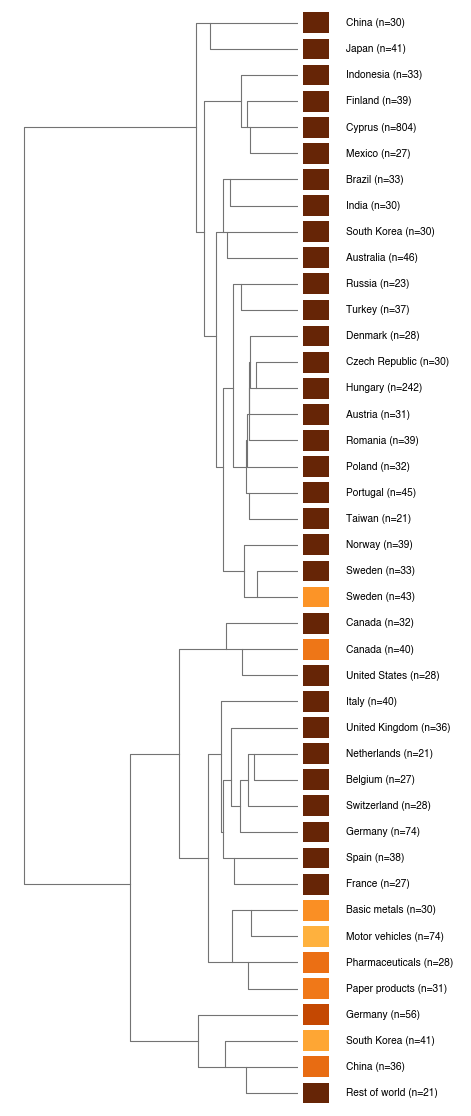

Saved figure -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/supp_fig_5/wiod_2014_condensed_dendrogram.png
Saved PNG    -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/png/supp_fig_5/wiod_2014_condensed_dendrogram.png


In [12]:
from himalayas.plot import plot_dendrogram_condensed

N_SIGNIFICANT_CLUSTERS = int(results_sig.df["cluster"].nunique())
print(f"Significant clusters to label: {N_SIGNIFICANT_CLUSTERS}")

condensed_dendrogram = plot_dendrogram_condensed(
    results_sig,
    rank_by="p",
    label_mode="top_term",
    label_overrides=CLUSTER_LABEL_OVERRIDES,
    figsize=(4.8, 0.29 * N_SIGNIFICANT_CLUSTERS),
    sigbar_cmap="YlOrBr",
    sigbar_min_logp=0.0,
    sigbar_max_logp=enrichment_norm_max,
    sigbar_width=0.055,
    sigbar_height=0.80,
    font=FONT,
    fontsize=7.3,
    max_words=18,
    wrap_text=True,
    wrap_width=24,
    overflow="ellipsis",
    label_fields=("label", "n"),
    label_color=LABEL_COLOR,
    label_left_pad=0.035,
    dendrogram_color=DENDRO_COLOR,
    dendrogram_lw=0.8,
    background_color=BACKGROUND_COLOR,
)

CONDENSED_DENDROGRAM_PATH = NB_FIGURES_DIR / "wiod_2014_condensed_dendrogram.png"
PNG_CONDENSED_PATH = PNG_SUPP5_DIR / "wiod_2014_condensed_dendrogram.png"
for path in (CONDENSED_DENDROGRAM_PATH, PNG_CONDENSED_PATH):
    condensed_dendrogram.save(
        path,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.03,
    )
condensed_dendrogram.show()

print(f"Saved figure -> {CONDENSED_DENDROGRAM_PATH}")
print(f"Saved PNG    -> {PNG_CONDENSED_PATH}")

## Summarize Destination Flows

For selected country-labeled clusters, sum raw intermediate flow to concrete cross-border destination country-sectors. Same-country and Rest-of-world destinations are excluded so the panel shows named destinations rather than domestic or aggregate flows.


In [13]:
import re as _re

COUNTRY_TERM_RE = _re.compile(r"^[A-Z]{3}$")
N_TOP_CLUSTERS = 15
N_TOP_DESTINATIONS = 5
EXCLUDED_DESTINATION_COUNTRIES = ("ROW",)  # aggregate "Rest of world", not a concrete country-sector


def select_top_country_clusters(cluster_labels_df, n=N_TOP_CLUSTERS):
    """Return the n most significant clusters whose top term is a country code."""
    is_country = cluster_labels_df["label"].str.fullmatch(COUNTRY_TERM_RE)
    country_clusters = cluster_labels_df[is_country].sort_values("pval")
    return country_clusters.head(n).reset_index(drop=True)


def summarize_top_destinations(flow_block, clusters, cluster_id, country, top_n=N_TOP_DESTINATIONS):
    """Return top raw-flow destinations, excluding domestic and ROW columns."""
    origin_rows = sorted(clusters.cluster_to_labels[cluster_id])
    dest_totals = flow_block.loc[origin_rows].sum(axis=0)
    excluded_prefixes = (f"{country}_",) + tuple(f"{c}_" for c in EXCLUDED_DESTINATION_COUNTRIES)
    concrete = dest_totals[~dest_totals.index.str.startswith(excluded_prefixes)]
    return concrete.sort_values(ascending=False).head(top_n)


top_country_clusters = select_top_country_clusters(cluster_labels)
print(f"Selected {len(top_country_clusters)} top country-labeled clusters:")
print(top_country_clusters[["cluster", "label", "pval"]].to_string(index=False))

# Defensive check: confirm every selected cluster still has a full top-5 of concrete
# (non-same-country, non-ROW) cross-border destinations after the added exclusion.
for row in top_country_clusters.itertuples(index=False):
    n_available = len(
        summarize_top_destinations(flow_block, results_sig.clusters, row.cluster, row.label)
    )
    if n_available < N_TOP_DESTINATIONS:
        print(
            f"WARNING: cluster {row.cluster} ({row.label}) has only {n_available}/"
            f"{N_TOP_DESTINATIONS} concrete cross-border destinations after excluding "
            "same-country and ROW destinations."
        )
    else:
        print(f"OK: cluster {row.cluster} ({row.label}) has a full top-{N_TOP_DESTINATIONS}.")

Selected 15 top country-labeled clusters:
 cluster label         pval
      10   AUS 2.885304e-88
      19   PRT 6.345045e-86
      27   ITA 1.008884e-74
       2   JPN 4.109787e-73
      21   NOR 1.439143e-72
      17   ROU 1.439143e-72
      33   ESP 1.939645e-70
       4   FIN 7.509929e-69
      12   TUR 1.103987e-64
      28   GBR 1.241944e-62
       3   IDN 4.061684e-60
       7   BRA 4.061684e-60
      22   SWE 4.061684e-60
      24   CAN 4.115839e-58
      18   POL 4.115839e-58


OK: cluster 10 (AUS) has a full top-5.
OK: cluster 19 (PRT) has a full top-5.
OK: cluster 27 (ITA) has a full top-5.
OK: cluster 2 (JPN) has a full top-5.
OK: cluster 21 (NOR) has a full top-5.
OK: cluster 17 (ROU) has a full top-5.
OK: cluster 33 (ESP) has a full top-5.
OK: cluster 4 (FIN) has a full top-5.
OK: cluster 12 (TUR) has a full top-5.
OK: cluster 28 (GBR) has a full top-5.
OK: cluster 3 (IDN) has a full top-5.
OK: cluster 7 (BRA) has a full top-5.
OK: cluster 22 (SWE) has a full top-5.
OK: cluster 24 (CAN) has a full top-5.
OK: cluster 18 (POL) has a full top-5.


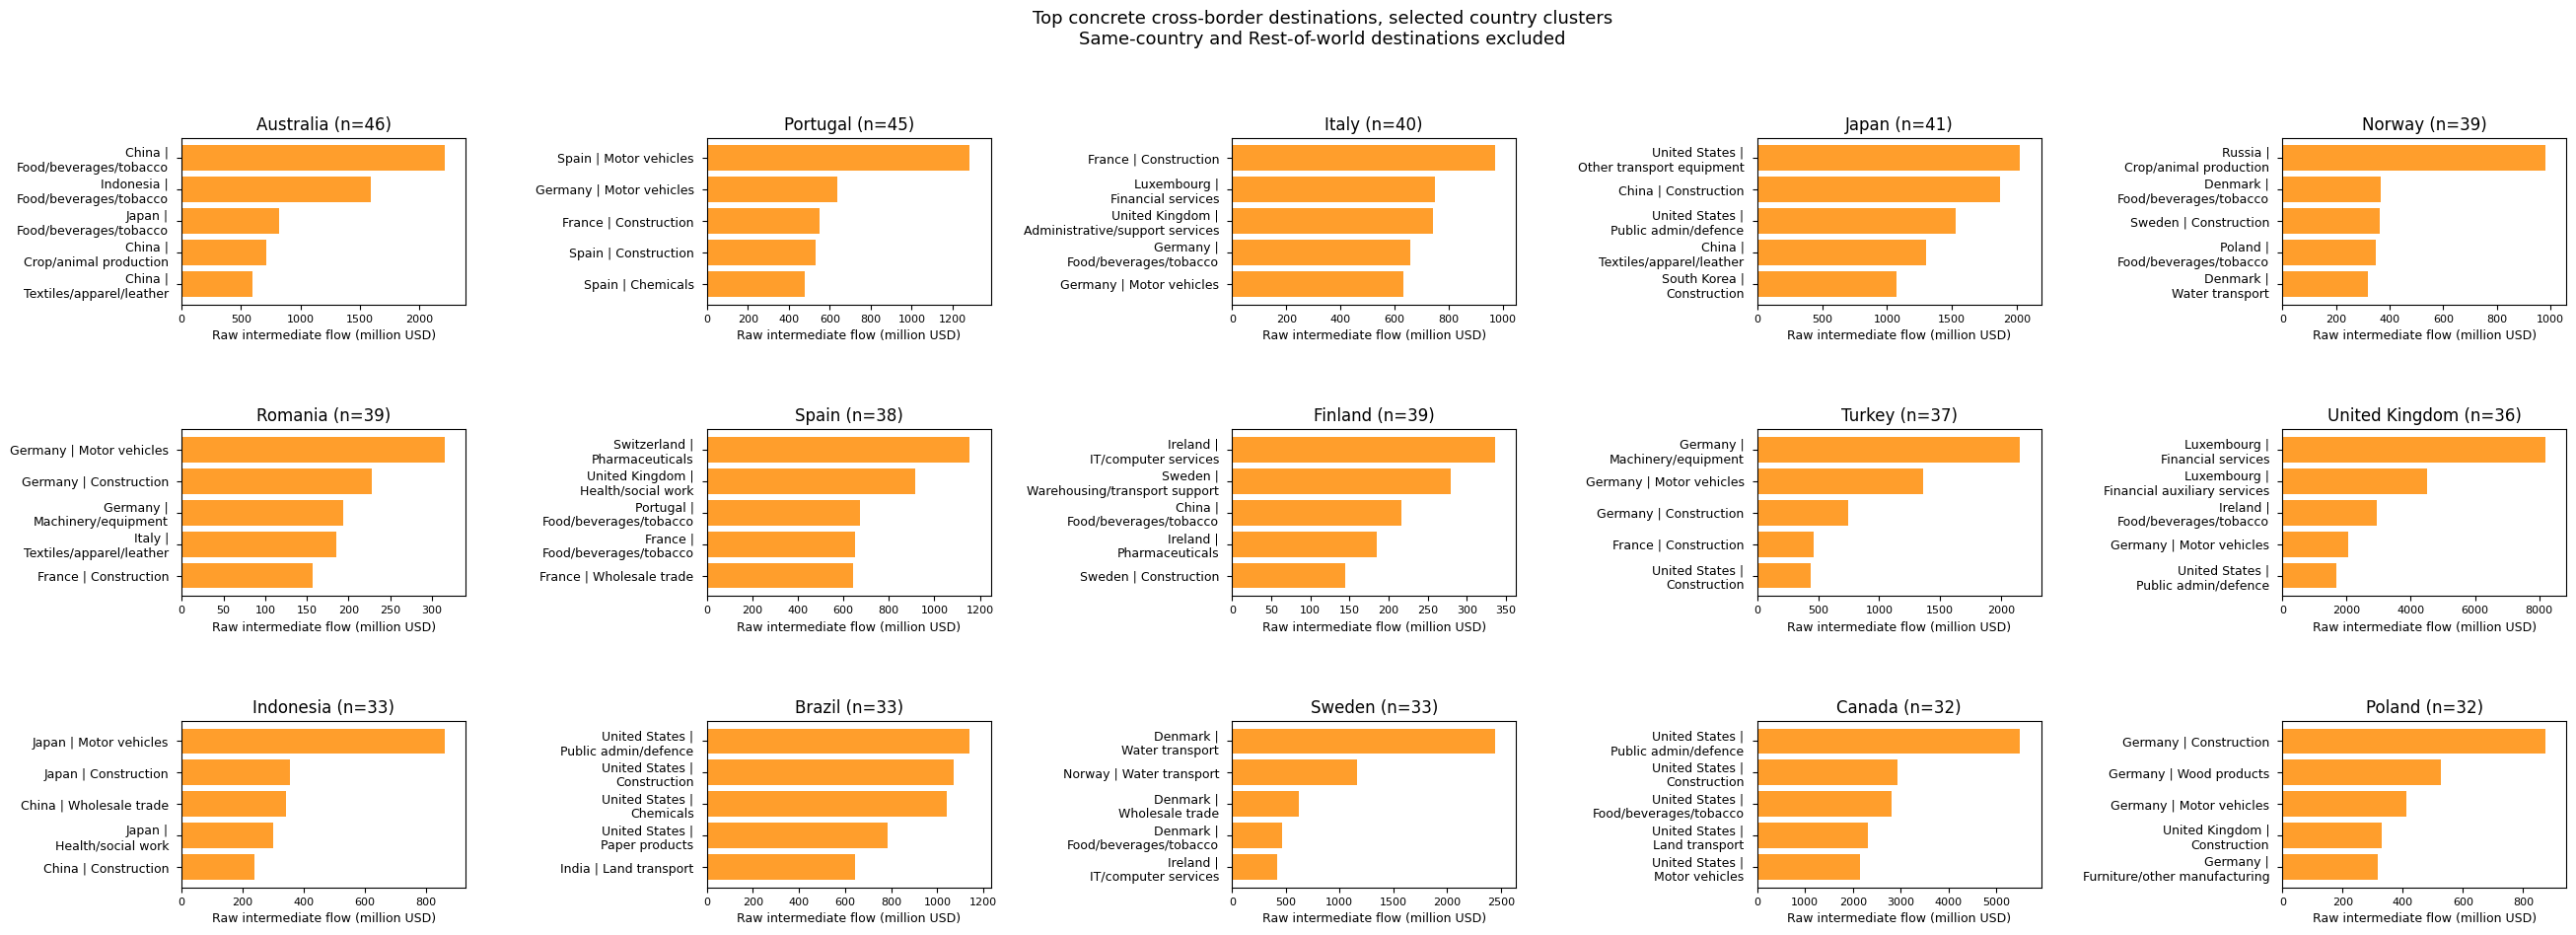

Saved figure -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/figures/supp_fig_5/wiod_2014_top_country_cluster_destinations.png
Saved PNG    -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/png/supp_fig_6/wiod_2014_top_country_cluster_destinations.png
Saved table -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/supp_fig_5/top_country_cluster_destinations.csv (75 rows)


In [14]:
DEST_BAR_COLOR = "#FF9E2C"


def wrap_destination_label(label, max_chars=24):
    """Wrap long destination labels at the country-sector separator."""
    if len(label) <= max_chars:
        return label
    country, sector = label.split(" | ", 1)
    return f"{country} |\n{sector}"


fig, axes = plt.subplots(
    3,
    5,
    figsize=(26, 10),
    squeeze=False,
)
fig.patch.set_facecolor(BACKGROUND_COLOR)
fig.subplots_adjust(left=0.055, right=0.985, top=0.85, bottom=0.09, wspace=0.85, hspace=0.75)

destination_records = []
for ax, row in zip(axes.flat, top_country_clusters.itertuples(index=False)):
    ax.set_facecolor(BACKGROUND_COLOR)
    top_dest = summarize_top_destinations(flow_block, results_sig.clusters, row.cluster, row.label)

    for rank, (dest_label, flow_value) in enumerate(top_dest.items(), start=1):
        destination_records.append(
            {
                "cluster": row.cluster,
                "cluster_label": row.label,
                "rank": rank,
                "destination": dest_label,
                "destination_readable": readable_destination_label(dest_label),
                "flow_million_usd": float(flow_value),
            }
        )

    bar_labels = [
        wrap_destination_label(readable_destination_label(lbl)) for lbl in top_dest.index
    ][::-1]
    bar_values = top_dest.values[::-1]
    ax.barh(bar_labels, bar_values, color=DEST_BAR_COLOR)
    ax.tick_params(axis="y", pad=6)
    ax.set_xlim(0, float(bar_values.max()) * 1.08)
    n_rows = len(results_sig.clusters.cluster_to_labels[row.cluster])
    ax.set_title(
        f"{COUNTRY_NAME[row.label]} (n={n_rows})", fontsize=12, color=LABEL_COLOR
    )
    ax.set_xlabel("Raw intermediate flow (million USD)", fontsize=9, color=LABEL_COLOR)
    for spine in ax.spines.values():
        spine.set_color(LABEL_COLOR)
    ax.tick_params(axis="x", labelsize=8, colors=LABEL_COLOR)
    ax.tick_params(axis="y", labelsize=9, colors=LABEL_COLOR)

fig.suptitle(
    "Top concrete cross-border destinations, selected country clusters\n"
    "Same-country and Rest-of-world destinations excluded",
    fontsize=13,
    y=0.98,
    color=LABEL_COLOR,
)

DEST_FIGURE_PATH = NB_FIGURES_DIR / "wiod_2014_top_country_cluster_destinations.png"
PNG_DEST_FIGURE_PATH = PNG_SUPP6_DIR / "wiod_2014_top_country_cluster_destinations.png"
for path in (DEST_FIGURE_PATH, PNG_DEST_FIGURE_PATH):
    fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.05, facecolor=BACKGROUND_COLOR)
plt.show()

print(f"Saved figure -> {DEST_FIGURE_PATH}")
print(f"Saved PNG    -> {PNG_DEST_FIGURE_PATH}")

DEST_TABLE_PATH = NB_TABLES_DIR / "top_country_cluster_destinations.csv"
destination_df = pd.DataFrame(destination_records)
destination_df.to_csv(DEST_TABLE_PATH, index=False)
print(f"Saved table -> {DEST_TABLE_PATH} ({len(destination_df):,} rows)")

## Save Outputs

Write tables and a compact provenance manifest.


In [15]:
TABLE_PATH = NB_TABLES_DIR / "enrichment_results_significant.csv"
results_sig.df.to_csv(TABLE_PATH, index=False)
print(f"Saved table -> {TABLE_PATH} ({len(results_sig.df):,} rows)")

manifest = {
    "notebook_id": NB_ID,
    "generated_utc": ru.utc_timestamp(),
    "himalayas_version": himalayas.__version__,
    "source": {
        "dataset": "WIOD 2016 release",
        "doi": WIOD_DOI,
        "citation": (
            "Timmer, M. P., Dietzenbacher, E., Los, B., Stehrer, R. and de Vries, G. "
            "(2015), An Illustrated User Guide to the World Input-Output Database: the "
            "Case of Global Automotive Production, Review of International Economics, "
            "23: 575-605."
        ),
        "archive_file": "WIOTS_in_R.zip",
        "archive_sha256": archive_sha256,
        "archive_size_bytes": archive_size_bytes,
        "year_used": WIOD_YEAR,
        "rdata_member": WIOD_RDATA_FILENAME,
    },
    "matrix": {
        "raw_loaded_shape": list(wiot.shape),
        "intermediate_block_shape": list(flow_block.shape),
        "transform": "np.log1p",
        "route": "A -- row feature-vector clustering of the directed intermediate-flow "
        "profile matrix (not converted to a similarity matrix)",
    },
    "annotations": {
        "isic_sector_terms": len(sector_to_labels),
        "country_terms": len(country_to_labels),
        "domestic_cross_border": "dropped -- not a well-defined row-level annotation",
    },
    "clustering": {
        "linkage_method": "ward",
        "linkage_metric": "euclidean",
        "linkage_threshold": "auto",
        "optimal_ordering": USE_OPTIMAL_ORDERING,
        "min_cluster_size": MIN_CLUSTER_SIZE,
        "min_overlap": 2,
    },
    "results": {
        "total_enrichment_rows": int(len(results.df)),
        "significant_rows_q_le_0_05": int(len(results_sig.df)),
    },
    "condensed_dendrogram": {
        "description": "Compact visual summary of the same results_sig clustering/enrichment result shown in the main matrix figure, with cluster labels selected by the most significant native annotation term and rendered as human-readable country/sector names (rank_by='p', label_mode='top_term'). Not a separate validation analysis.",
        "n_clusters_labeled": N_SIGNIFICANT_CLUSTERS,
        "sigbar_max_logp": enrichment_norm_max,
    },
    "destination_flow_summary": {
        "description": "Descriptive 3-by-5 small-multiple bar summary (not enrichment) of raw intermediate flow summed across each selected cluster's origin rows, by destination country-sector column, with same-country and Rest-of-world (ROW) destinations excluded so only concrete, individually named cross-border destinations are shown.",
        "n_top_clusters": int(len(top_country_clusters)),
        "n_top_destinations_per_cluster": N_TOP_DESTINATIONS,
        "selected_cluster_labels": top_country_clusters["label"].tolist(),
        "value_basis": "raw (million USD), not log1p",
        "excluded_destination_countries": list(EXCLUDED_DESTINATION_COUNTRIES),
    },
    "outputs": {
        "figure": str(FIGURE_PATH.relative_to(REPO_ROOT)),
        "figure_png": str(PNG_MATRIX_PATH.relative_to(REPO_ROOT)),
        "condensed_dendrogram_figure": str(CONDENSED_DENDROGRAM_PATH.relative_to(REPO_ROOT)),
        "condensed_dendrogram_png": str(PNG_CONDENSED_PATH.relative_to(REPO_ROOT)),
        "table": str(TABLE_PATH.relative_to(REPO_ROOT)),
        "destination_summary_figure": str(DEST_FIGURE_PATH.relative_to(REPO_ROOT)),
        "destination_summary_png": str(PNG_DEST_FIGURE_PATH.relative_to(REPO_ROOT)),
        "destination_summary_table": str(DEST_TABLE_PATH.relative_to(REPO_ROOT)),
    },
}

MANIFEST_PATH = layout["manifests_dir"] / f"{NB_ID}_manifest.json"
ru.write_manifest(manifest, MANIFEST_PATH)
print(f"Saved manifest -> {MANIFEST_PATH}")

Saved table -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/tables/supp_fig_5/enrichment_results_significant.csv (133 rows)
Saved manifest -> /Users/irahorecka/Desktop/harddrive_desktop/PhD/University of Toronto/Rost Lab/GitHub/himalayas-publication/revision/outputs/manifests/supp_fig_5_manifest.json


## Claim Boundary

This notebook supports one auxiliary claim: HiMaLAYAS can annotate hierarchical structure in a non-biological, dense economic matrix using native metadata. The WIOD result is a portability example, not an economic-discovery claim and not a validation of the yeast GI-PCC analysis. No robustness, null, multi-year, or competing-dataset analysis is performed here.
